# Sensitivity of SPB Targets to Data and Assumptions

This notebook tests the sensitivity of SPB targets to the data and the model assumptions in the DSA model. The baseline is close to the reference trajectories of the Commission prior guidance of 2024: it uses the input workbook built from the Commission calculation sheets and the Commission implementation of the rules (`rules='commission'`).

Each run records two targets:

- the **DSA target**: the SPB required by the DSA criteria alone (debt declines or stays below 60% in the deterministic scenarios, deficit below 3%, stochastic criterion);
- the **binding target**: the SPB after the excessive deficit procedure (EDP), the debt sustainability safeguard and the deficit resilience safeguard are added.

The settings fall into four kinds, which answer different questions (`KINDS` in `code/functions/sensitivity.py`):

- **A. Assumptions about the economy** (`ECONOMY_ASSUMPTIONS`): real short- and long-term interest rates and inflation at T+10 and T+30, potential growth, the change in ageing costs, the budget semi-elasticity, the fiscal multiplier and its persistence, and the repayment profile of debt. How uncertain are the targets because the future is unknown?
- **B. Measurement of uncertainty** (`MEASUREMENT_ASSUMPTIONS`): shocks during the adjustment period, length of the stochastic projection, shock sample, frequency, distribution and winsorisation. How much do the targets depend on how the DSA estimates risk?
- **C. Rule calibration** (`CALIBRATION_SETTINGS`): probability target, size of the three stress tests and ageing cost period. These express how much risk the rules accept and have no true value; they are not drawn, but shown one at a time and in a lenient and a strict scenario (`CALIBRATION_SCENARIOS`).
- **D. Data and definitions**: the data update to the latest vintage, and stock-flow adjustments after T (non-zero after the forecast years only for Finland, Luxembourg and Greece, a question of gross versus net debt).

The ranges of the assumptions are a judgement of plausible alternatives. All drawn assumptions are drawn independently; interest rate assumptions are real rates (inflation shifts move nominal rates with them).

## Main findings

To be updated with the results of the redesigned analysis.

## TOC
1. **Individual checks.** Each check changes one setting at a time, grouped by kind (A to D). Runs with nine other random seeds give a noise band.
2. **Global sensitivity analysis.** Two sets of random draws: the assumptions about the economy alone (A), and together with the measurement settings (A and B), all other settings at the baseline. For each country, the 10th and the 90th percentile of the draws give an accommodative and a restrictive combination of assumptions; a variance decomposition shows which assumptions matter; the rule calibration (C) is compared in a table by country.
3. **Results tables**, displayed and saved to `output/sensitivity/`.
4. **Annex.** Individual checks for a 7-year adjustment period.

Runs are cached in `output/sensitivity/`: with `RUN = True`, the notebook computes only runs that are not in the cache. The individual checks take about 50 minutes on 12 cores, each set of 1000 global draws about 7 hours (all runs include the stochastic criterion, about 10 seconds per run). `QUICK = True` runs a subset of countries and fewer global draws for testing. The helper functions are in `code/functions/sensitivity.py`.

For comments and suggestions please contact lennard.welslau[at]gmail[dot]com.\
Last update: October 2026

In [1]:
# Import libraries and modules
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown
plt.rcParams.update({'axes.grid': True, 'grid.color': 'black', 'grid.alpha': 0.15, 'grid.linestyle': '--', 'font.size': 12,
                     'figure.dpi': 100, 'axes.titleweight': 'bold'})

# Import the DSA model classes and functions from the code folder
sys.path.append(os.path.abspath('..'))
from classes import StochasticDsaModel as DSA
from data_pipeline import EU27, latest_input_file
from functions.sensitivity import *

# Set autoreload
%load_ext autoreload
%autoreload 2

## Settings

In [2]:
INPUT_FILE = 'dsa_inputs_commission_2024.xlsx'  # baseline input workbook (Commission prior guidance 2024)
BASELINE_RULES = 'commission'                    # rules of find_spb_binding in the baseline
MULTIPLIER_TYPE = 'pers'                         # fiscal multiplier with persistent effect in all runs (None: input file)
ADJUSTMENT_PERIODS = (4, 7)                      # adjustment periods of the individual checks
MAIN_PERIOD = 4                                  # period of the global analysis, text, charts and tables (others: annex)
COUNTRIES = EU27
SEED = 0                                         # random seed set before every run (noise band: seeds 1 to 9)
N_DRAWS = 1000                                   # draws of each global sensitivity analysis (JOINT_RUNS)
REAL_RATES = True                                # rate assumptions are real rates: nominal rates move with inflation
ADJUSTMENT_BOUND = 5                             # largest annual adjustment searched (pp.); safeguard infeasible above
MAX_WORKERS = None                               # worker processes, None uses all CPUs

QUICK = False                                    # True: subset of countries and fewer global draws (for testing)
QUICK_COUNTRIES = ['BEL', 'DEU', 'ESP', 'FRA', 'ITA', 'NLD']
RUN = True                                       # True: compute runs missing from the cache; False: use cached runs only

if QUICK:
    COUNTRIES, N_DRAWS = QUICK_COUNTRIES, 40

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
run_options = dict(countries=COUNTRIES, adjustment_periods=ADJUSTMENT_PERIODS, input_file=INPUT_FILE,
                   rules=BASELINE_RULES, seed=SEED, run=RUN, max_workers=MAX_WORKERS,
                   model_kwargs={'fiscal_multiplier_type': MULTIPLIER_TYPE} if MULTIPLIER_TYPE else None,
                   attributes={'adjustment_bound': ADJUSTMENT_BOUND} if ADJUSTMENT_BOUND != 3 else None)

## 1. Individual checks

### 1.1 Specification table

Each row changes one setting relative to the baseline. Checks are grouped by kind: assumptions about the economy, measurement of uncertainty, rule calibration (with the lenient and strict scenarios, in which all calibration settings are at one end of their range) and data and definitions. Input changes are relative to the baseline workbook: the notebook reads the baseline value with `read_country` and passes the new absolute value as an override. Potential growth is shifted together with baseline real growth, so that the output gap is unchanged. The ageing-cost check scales the change in ageing costs relative to T; the stock-flow check sets the stock-flow adjustment to zero after T. Interest rate and inflation checks shift the model paths as if the T+10 or T+30 anchor were different, with the linear interpolation the model uses between anchors (`shift_anchor`). With `REAL_RATES = True`, interest rate checks shift real rates: an inflation check moves the nominal short- and long-term rates by the same amount, so that real rates are unchanged.

In [3]:
oat_specs = build_oat_specs(latest_file=latest_input_file(), real_rates=REAL_RATES)
with pd.option_context('display.max_rows', 200, 'display.max_colwidth', 70):
    display(spec_table(oat_specs))

,group,check,variant,model arguments,attributes,input changes,find_spb_binding options,setup,other
id,,,,,,,,,
baseline,Baseline,Baseline,baseline,,,,,,
data:latest,Data,Data update,latest vintage (2026_09),,,,,,input file dsa_inputs_2026_09.xlsx
data:repayment_profile,Data,Repayment profile (Eurostat),residual maturity buckets,bond_data=True,,,,,
macro:rate_st_T10:-1,Macro,Short-term rate T+10,-1,,,,,"shift_anchor(variable=i_st, anchor=10, delta=-1)",
macro:rate_st_T10:+1,Macro,Short-term rate T+10,+1,,,,,"shift_anchor(variable=i_st, anchor=10, delta=1)",
macro:rate_lt_T10:-1,Macro,Long-term rate T+10,-1,,,,,"shift_anchor(variable=i_lt, anchor=10, delta=-1)",
macro:rate_lt_T10:+1,Macro,Long-term rate T+10,+1,,,,,"shift_anchor(variable=i_lt, anchor=10, delta=1)",
macro:rate_st_T30:-0.5,Macro,Short-term rate T+30,-0.5,,,,,"shift_anchor(variable=i_st, anchor=30, delta=-0.5)",
macro:rate_st_T30:+0.5,Macro,Short-term rate T+30,+0.5,,,,,"shift_anchor(variable=i_st, anchor=30, delta=0.5)",


### 1.2 Runs

The baseline and every check run for each country and adjustment period. The Commission targets are added for comparison: the published SPB at the end of the adjustment period (after the safeguards) and the target from the DSA criteria alone.

In [4]:
oat = run_specs(oat_specs, cache_file=OUTPUT_DIR / 'oat_runs.pkl', **run_options)
vintage = 'latest' if 'latest' in INPUT_FILE else '2024'
oat = oat.merge(commission_targets(COUNTRIES, vintage=vintage), on=['country', 'adjustment_period'], how='left')
oat = add_deviations(oat)
noise = noise_band(oat, target='dsa')
checks = oat[oat['group'] != 'Baseline']
print(f"{len(oat)} runs, {oat['error'].notna().sum() if 'error' in oat else 0} failed")

6 runs failed, see column 'error'


/usr/local/lib/python3.11/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


2970 runs, 6 failed


### 1.3 Baseline and Commission targets

The baseline is compared with the Commission targets, both from the DSA criteria alone and after the safeguards. The model reproduces them closely with the Commission's output gap closure rule (`MULTIPLIER_TYPE = None`, see `commission_replication.ipynb`); the persistent multiplier used here moves some targets by a few tenths of a percentage point.

In [5]:
base = oat[(oat['id'] == 'baseline') & (oat['adjustment_period'] == MAIN_PERIOD)].copy()
base['dsa difference'] = base['dsa_target'] - base['commission_dsa_target']
base['binding difference'] = base['binding_target'] - base['commission_target']
table = base.set_index('country')[['commission_dsa_target', 'dsa_target', 'dsa difference', 'commission_target',
                                   'binding_target', 'binding difference', 'binding_criterion']]
display(table.round(2))
print(f"Median absolute difference {base['dsa difference'].abs().median():.2f} pp. (DSA target), "
      f"{base['binding difference'].abs().median():.2f} pp. (binding target); "
      f"maximum {base['dsa difference'].abs().max():.2f} and {base['binding difference'].abs().max():.2f} pp.")

,commission_dsa_target,dsa_target,dsa difference,commission_target,binding_target,binding difference,binding_criterion
country,,,,,,,
AUT,0.90,0.82,-0.08,2.58,2.22,-0.36,debt_safeguard
BEL,1.25,1.21,-0.04,1.25,1.21,-0.04,debt_declines_adverse_r_g
BGR,NaN,-2.05,NaN,-0.87,-0.88,-0.01,deficit_reduction
HRV,NaN,-0.44,NaN,-0.36,-0.36,0.00,debt_below_60_main_adjustment
CYP,3.48,3.48,0.00,3.48,3.48,0.00,floor
CZE,NaN,0.39,NaN,0.39,0.39,0.00,deficit_reduction
DNK,NaN,-1.09,NaN,-1.09,-1.09,0.00,floor
EST,-0.29,-0.29,0.00,-0.29,-0.29,0.00,floor
FIN,2.11,1.83,-0.28,5.87,4.83,-1.04,debt_safeguard


Median absolute difference 0.04 pp. (DSA target), 0.01 pp. (binding target); maximum 0.28 and 1.04 pp.


### 1.4 Main table: effects of each check

Change of the SPB target relative to the baseline for each check variant, in pp. of GDP: mean, minimum and maximum across countries and the number of countries whose target changes by more than 0.1 pp. (whether an effect is broad or driven by a few countries), for the DSA target (DSA criteria only) and the binding target (DSA criteria, EDP and safeguards). The noise band from alternative seeds is printed above the table; effects within it are indistinguishable from simulation noise. Countries without data for a check (no Eurostat repayment profile for Hungary, Luxembourg and the Netherlands) are left out of its statistics.

In [6]:
main_table = effects_table(oat, (MAIN_PERIOD,))
main_noise = noise[noise['adjustment_period'] == MAIN_PERIOD]
print(f"Noise band (median half-width across countries, DSA target): {float((main_noise['noise_high'] - main_noise['noise_low']).median() / 2):.3f} pp.")
with pd.option_context('display.max_rows', 200):
    display(main_table.round(2))

Noise band (median half-width across countries, DSA target): 0.000 pp.


adjustment                                                               4-year adjustment  \
target                                                                        DSA criteria   
statistic                                                                             mean   
group        check                             variant                                       
Data         Data update                       latest vintage (2026_09)               0.22   
             Repayment profile (Eurostat)      residual maturity buckets             -0.01   
Macro        Short-term rate T+10              -1                                    -0.03   
                                               +1                                     0.03   
             Long-term rate T+10               -1                                    -0.19   
                                               +1                                     0.19   
             Short-term rate T+30              -0.5                                  -0.00   
                                               +0.5                                   0.00   
             Long-term rate T+30               -0.5                                  -0.01   
                                               +0.5                                   0.00   
             Inflation T+10                    -0.5                                   0.04   
                                               +0.5                                  -0.02   
             Inflation T+30                    -0.25                                  0.00   
                                               +0.25                                 -0.01   
             Potential growth                  -0.5                                   0.23   
                                               +0.5                                  -0.19   
             Ageing cost change (scale)        x0.5                                  -0.26   
                                               x1.5                                   0.27   
             Stock-flow adjustment             zero after T                          -0.08   
             Ageing cost period                5 years                               -0.21   
             Budget balance elasticity (scale) x0.8                                  -0.02   
                                               x1.2                                   0.03   
Multiplier   Fiscal multiplier                 0.25                                  -0.04   
                                               0.5                                   -0.03   
                                               1                                      0.05   
                                               1.25                                   0.11   
             Multiplier persistence            1 years                               -0.04   
                                               2 years                               -0.02   
                                               4 years                                0.03   
                                               5 years                                0.06   
Stress tests Adverse r-g shock                 0.25                                  -0.05   
                                               0.75                                   0.12   
             Financial stress shock            0.5                                    0.00   
                                               1.5                                    0.00   
             Lower SPB shock                   0.25                                  -0.00   
                                               0.75                                   0.04   
Stochastic   Probability target                0.6                                   -0.00   
                                               0.8                                    0.03   
             Stochastic period                 10 ye

### 1.5 Which checks matter most

Mean change of the SPB target across countries for each check variant: bars for the DSA target, diamonds for the binding target. Means keep the sign of the changes, so a check that raises the target in some countries and lowers it in others can have a small mean; the range across countries is in the main table.

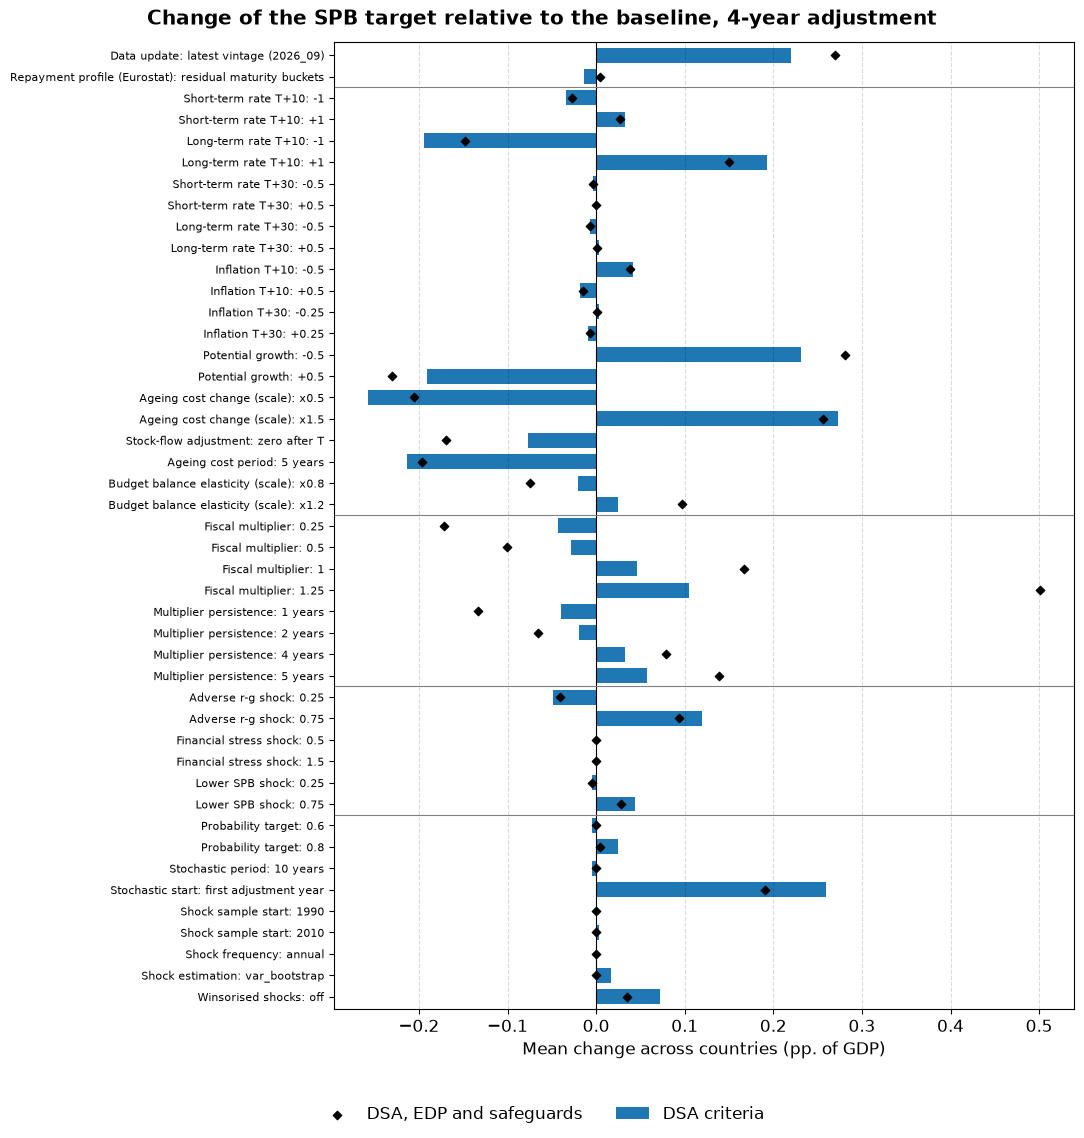

In [7]:
plot_mean_effects(oat, (MAIN_PERIOD,))
plt.show()

## 2. Global sensitivity analysis

Individual checks miss interactions: a higher interest rate may matter more once growth is low. The global analysis draws several assumptions at once, in two sets (`JOINT_RUNS`): the assumptions about the economy alone (`economy`, the main analysis) and together with the measurement settings (`economy_measurement`). The difference between the two shows how much the measurement of uncertainty adds. The rule calibration, stock-flow adjustments and the data stay at the baseline in both. Continuous assumptions are drawn uniformly over the range of their values in the individual checks, discrete settings with equal probability for each setting, the baseline setting included. All assumptions are drawn independently; interest rate draws are real rates (`REAL_RATES`). Each draw is a full run with the stochastic criterion, for the 4-year adjustment period. The annual adjustment is searched up to `ADJUSTMENT_BOUND` (5 pp.); draws in which the debt sustainability safeguard cannot be met even at this bound are flagged as infeasible (`safeguard_infeasible`) and left out of the percentiles and the variance decomposition of the binding target.

For each country, the 10th percentile of the target across draws is the accommodative and the 90th percentile the restrictive combination of assumptions, separately for the DSA target and the binding target. Because the assumptions are drawn independently, the outer tails contain combinations that are economically implausible jointly (for example a high real interest rate with low potential growth, or a large multiplier with a very persistent effect); the 10th and 90th percentiles do not depend on them. The table shows their change relative to the baseline, as in the main table (section 1.4), for both sets of draws.

In [ ]:
joint = {}
for name, assumptions in JOINT_RUNS.items():
    specs = build_global_specs(n_draws=N_DRAWS, seed=SEED, assumptions=assumptions, real_rates=REAL_RATES)
    runs = run_specs(specs, cache_file=OUTPUT_DIR / f'global_runs_{name}.pkl', **{**run_options, 'adjustment_periods': (MAIN_PERIOD,)})
    joint[name] = add_deviations(runs)
glob, glob_meas = joint['economy'], joint['economy_measurement']   # main analysis: assumptions about the economy
draws, draws_meas = glob[glob['group'] == 'Global'], glob_meas[glob_meas['group'] == 'Global']
combinations = draw_combinations(glob)
results = add_deviations(pd.concat([oat, combinations], ignore_index=True))
combined_table = pd.concat({name: effects_table(draw_combinations(g), (MAIN_PERIOD,)) for name, g in joint.items()},
                           names=['draws'])
display(combined_table.round(2))

### 2.1 Range of targets relative to the required adjustment

By country: the adjustment that the baseline binding target requires (binding target minus the SPB in T), the band between the 10th and 90th percentile of the targets for both sets of draws, the position of the baseline in the economy draws (share of draws with a lower target), the number of infeasible draws and the share of draws whose binding target requires a total adjustment of more than 6 pp.

In [ ]:
q_lo, q_hi = COMBINATIONS['draws:accommodative'][1], COMBINATIONS['draws:restrictive'][1]
base_main = oat[(oat['id'] == 'baseline') & (oat['adjustment_period'] == MAIN_PERIOD)].set_index('country')
rows = []
for c in COUNTRIES:
    row = {'country': c, 'required adjustment': base_main.loc[c, 'binding_target'] - base_main.loc[c, 'spb_T']}
    for name, d in [('economy', draws), ('economy and measurement', draws_meas)]:
        dc = d[d['country'] == c]
        for target in ['dsa', 'binding']:
            x = feasible(dc, target)[TARGETS[target]['target']].dropna()
            row[f'{target} band ({name})'] = x.quantile(q_hi) - x.quantile(q_lo)
            if name == 'economy':
                row[f'{target} baseline rank'] = (x < base_main.loc[c, TARGETS[target]['target']] - 1e-9).mean()
        row[f'infeasible draws ({name})'] = int(dc['safeguard_infeasible'].sum())
    dc = draws[draws['country'] == c]
    row['share > 6 pp. (economy)'] = ((dc['binding_target'] - dc['spb_T']) > 6 + 1e-9).mean()
    rows.append(row)
bands = pd.DataFrame(rows).set_index('country')
display(bands.round(2))
print('Median:', bands.median().round(2).to_dict())

### 2.2 Which assumptions matter

The variance of the target across draws is split by country with squared standardised regression coefficients: the share of the variance explained linearly by each assumption. Continuous assumptions and settings with numeric values (e.g. multiplier persistence, shock sample start) enter linearly, on/off settings as 0/1 indicators. The draws are close to uncorrelated, so the shares add up to the R² of the regression; the rest is due to non-linear effects and interactions, mostly switches of the binding criterion. For the binding target, infeasible draws are left out. The table aggregates over countries, weighting each country by the variance of its target, so the shares refer to the variance summed over countries and are dominated by the countries whose target varies most; the shares by country are saved in `output/sensitivity/sensitivity_results.xlsx`. The last row is the mean standard deviation of the target across countries.

In [ ]:
vd = pd.concat([variance_decomposition(d, target=t, assumptions=JOINT_RUNS[name],
                                       categories=ECONOMY_CATEGORIES if name == 'economy' else GLOBAL_CATEGORIES).assign(draws=name)
                for name, d in [('economy', draws), ('economy_measurement', draws_meas)] for t in ['dsa', 'binding']],
               ignore_index=True)
variance = pd.concat({
    'economy': variance_table(vd[vd['draws'] == 'economy'], ECONOMY_ASSUMPTIONS, ECONOMY_CATEGORIES),
    'economy_measurement': variance_table(vd[vd['draws'] == 'economy_measurement'], GLOBAL_ASSUMPTIONS, GLOBAL_CATEGORIES),
}, axis=1)
display(variance.round(2))

### 2.3 Range of targets by country

Targets by country, ordered by the baseline target. The grey bar spans the targets of the individual checks of the assumptions about the economy and the measurement settings; green and red markers show the 10th and the 90th percentile of the economy draws (binding target without infeasible draws). Markers also show the baseline, the Commission target and the SPB in T; the distance between the SPB in T and a target is the adjustment the target requires. DSA targets first, then binding targets (Commission target as published).

In [ ]:
for target in ['dsa', 'binding']:
    plot_ranges(results[~results['group'].isin([CALIBRATION, DATA])], MAIN_PERIOD, target=target)
    plt.show()

### 2.4 Debt paths by country

Debt under a linear adjustment to the DSA target of the baseline and of the draws closest to the 10th and the 90th percentile of the economy draws (green, red), with the range across the individual checks of the assumptions about the economy and the measurement settings in grey.

In [ ]:
plot_debt_paths(results[~results['group'].isin([CALIBRATION, DATA])], adjustment_period=MAIN_PERIOD, target='dsa')
plt.show()

### 2.5 Rule calibration

Targets by country with the baseline calibration, the probability target at 60% and 80%, and the lenient and strict calibration scenarios (`CALIBRATION_SCENARIOS`): the price of a given tolerance for risk.

In [ ]:
cal_ids = ['baseline', 'stochastic:prob_target:0.6', 'stochastic:prob_target:0.8', 'calibration:lenient', 'calibration:strict']
cal = oat[(oat['adjustment_period'] == MAIN_PERIOD) & oat['id'].isin(cal_ids)]
calibration = pd.concat({t: cal.pivot(index='country', columns='id', values=TARGETS[t]['target'])[cal_ids]
                         for t in ['dsa', 'binding']}, axis=1)
display(calibration.round(2))
print('Mean change relative to the baseline:', (calibration.sub(calibration.xs('baseline', axis=1, level=1), level=0)).mean().round(2).to_dict())

## 3. Results tables

The main result tables, also saved to `output/sensitivity/sensitivity_results.xlsx` together with the tidy results (one row per run, sheets `runs`, `global_runs_economy` and `global_runs_economy_measurement`) and the variance shares by country. Columns with dictionaries (SPB targets by criterion, debt paths) are kept in the cached runs (`*.pkl`).

In [ ]:
# Result tables
tables = {
    'Baseline and Commission targets (1.3)': table,
    'Effects of each individual check (1.4)': main_table,
    '10th and 90th percentile of the global draws (2)': combined_table,
    'Range of targets relative to the required adjustment (2.1)': bands,
    'Variance decomposition of the global analysis (2.2)': variance,
    'Rule calibration (2.5)': calibration,
    'Specifications of the individual checks': spec_table(oat_specs),
}
for title, t in tables.items():
    display(Markdown(f'**{title}**'))
    with pd.option_context('display.max_rows', 200, 'display.max_colwidth', 70):
        display(t.round(2))

# Save, with the annex table (section 4)
annex = effects_table(oat, tuple(n for n in ADJUSTMENT_PERIODS if n != MAIN_PERIOD))
flat = lambda df: df.drop(columns=[c for c in ['spb_target_dict', 'debt_path', 'dsa_debt_path'] if c in df])
sheets = {'effects': main_table, 'annex_effects': annex, 'global_combinations': combined_table, 'bands': bands,
          'global_variance': variance, 'calibration': calibration, 'baseline_commission': table,
          'specs': tables['Specifications of the individual checks']}
with pd.ExcelWriter(OUTPUT_DIR / 'sensitivity_results.xlsx') as writer:
    flat(results).to_excel(writer, sheet_name='runs', index=False)
    for name, t in sheets.items():
        t.to_excel(writer, sheet_name=name, index=not isinstance(t.index, pd.RangeIndex))
    for name, g in joint.items():
        flat(g).to_excel(writer, sheet_name=f'global_runs_{name}'[:31], index=False)
    vd.to_excel(writer, sheet_name='global_variance_by_country', index=False)
print(f"Saved to {OUTPUT_DIR / 'sensitivity_results.xlsx'}")

## 4. Annex: 7-year adjustment

Effects of each individual check on the SPB target for a 7-year adjustment period, as in the main table (section 1.4): mean, minimum and maximum change relative to the baseline across countries and the number of countries with a change above 0.1 pp., for the DSA target and the binding target (pp. of GDP). The global analysis covers the 4-year adjustment period only.

In [13]:
with pd.option_context('display.max_rows', 200):
    display(annex.round(2))

adjustment                                                               7-year adjustment  \
target                                                                        DSA criteria   
statistic                                                                             mean   
group        check                             variant                                       
Data         Data update                       latest vintage (2026_09)               0.26   
             Repayment profile (Eurostat)      residual maturity buckets             -0.01   
Macro        Short-term rate T+10              -1                                    -0.04   
                                               +1                                     0.04   
             Long-term rate T+10               -1                                    -0.23   
                                               +1                                     0.26   
             Short-term rate T+30              -0.5                                  -0.00   
                                               +0.5                                   0.00   
             Long-term rate T+30               -0.5                                  -0.01   
                                               +0.5                                   0.02   
             Inflation T+10                    -0.5                                   0.04   
                                               +0.5                                   0.02   
             Inflation T+30                    -0.25                                  0.01   
                                               +0.25                                 -0.01   
             Potential growth                  -0.5                                   0.26   
                                               +0.5                                  -0.19   
             Ageing cost change (scale)        x0.5                                  -0.22   
                                               x1.5                                   0.27   
             Stock-flow adjustment             zero after T                          -0.06   
             Ageing cost period                5 years                               -0.17   
             Budget balance elasticity (scale) x0.8                                  -0.01   
                                               x1.2                                   0.02   
Multiplier   Fiscal multiplier                 0.25                                  -0.02   
                                               0.5                                   -0.01   
                                               1                                      0.02   
                                               1.25                                   0.05   
             Multiplier persistence            1 years                               -0.02   
                                               2 years                               -0.01   
                                               4 years                                0.02   
                                               5 years                                0.04   
Stress tests Adverse r-g shock                 0.25                                  -0.03   
                                               0.75                                   0.13   
             Financial stress shock            0.5                                    0.00   
                                               1.5                                    0.00   
             Lower SPB shock                   0.25                                  -0.00   
                                               0.75                                   0.04   
Stochastic   Probability target                0.6                                    0.00   
                                               0.8                                    0.09   
             Stochastic period                 10 ye